<a href="https://colab.research.google.com/github/xolidausmonovaa-lang/ctf-game-hacking/blob/main/Usmonova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, mean_squared_error

In [38]:
import os
print(os.listdir())

['.config', 'global air pollution dataset.csv', 'archive.zip', 'sample_data']


In [39]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [40]:
import os
print(os.listdir())

['.config', 'global air pollution dataset.csv', 'archive.zip', 'sample_data']


In [41]:
df = pd.read_csv("global air pollution dataset.csv")
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [42]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [43]:
df = df.dropna()

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

target_reg = 'AQI Value'

X_reg = df.drop(columns=[target_reg])
y_reg = df[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

y_pred_lr = lr.predict(X_test_r)

print("Linear Regression MSE:", mean_squared_error(y_test_r, y_pred_lr))

Linear Regression MSE: 72.1912321212426


In [46]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_r)
X_test_poly = poly.transform(X_test_r)

pr = LinearRegression()
pr.fit(X_train_poly, y_train_r)

y_pred_pr = pr.predict(X_test_poly)

print("Polynomial Regression MSE:", mean_squared_error(y_test_r, y_pred_pr))

Polynomial Regression MSE: 44.81289964564623


In [32]:
target_clf = 'AQI Category'

X = df.drop(columns=[target_clf])
y = df[target_clf]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7056652919470371


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9997829390058607


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9991317560234426


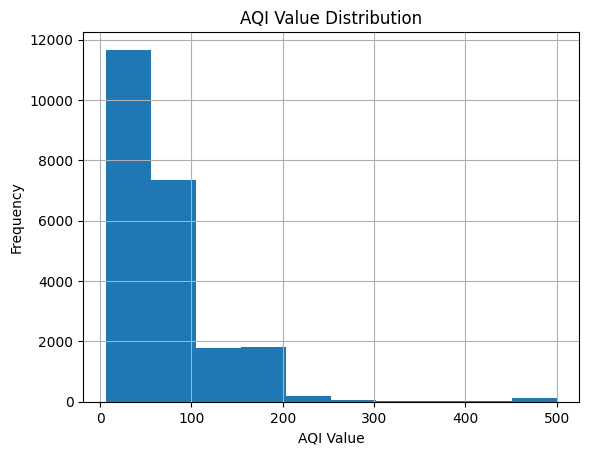

In [36]:
import matplotlib.pyplot as plt

df['AQI Value'].hist()
plt.title("AQI Value Distribution")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

Bu loyihada men global havo ifloslanishi bo'yicha datasetdan foydalandim. Avval ma'lumotlarni tozaladim va matn ko'rishdagi qiymatlarni raqamlarga o'tkazdim.

Keyin regressiya va klassifikatsiya algoritmlarini sinab ko'rdim. Regressiyada chiziqli va polinom modellardan ishonchli, AQI aniqlashni bashorat qilaman.

Klassifikatsiyada esa Logistic Regression, Decision Tree, Random Forest va SVM algoritmlarini qo'lladim va hujjatni tahlil qildim.

zararli Random Forest eng yaxshi ishlaganini ko'rdim, chunki u ancha aniq natija berdi.

Yana grafik orqali AQI narxlari qanday taqsimlanganini ham ko'rsataman.

Umuman olganda, bu ma'lumotlarni olish orqali men mashinaviy o'rganish algoritmlarini real loyihalarda qo'llashni va ularni solishtirishni o'rgandim.